# Experiment 6: Are remote data science jobs less entry-level friendly?

**Research question:** Are remote data science postings disproportionately senior, making them less accessible to entry-level candidates?

**Expected finding:** Remote data science postings will skew more senior and include fewer entry-level roles than non-remote postings.

**Why it matters:** If remote jobs skew senior, job seekers using remote-only filters may unknowingly narrow themselves into a tougher experience bracket.

**Unified columns used:** `job_title` and `location`

## Outputs for midterm report

* (1) Variable / Inputs: 2,317 unified job postings with usable location, split into Remote (328) and Non-remote (1,989), with title-derived seniority groups: Entry-level (59), Mid-level (1,894), and Senior+ (364).
* (2) Model (max 10 words): Chi-square test of remote status and title-derived seniority.
* (3) Finding Statement (max 15 words): Remote data science jobs skew senior and are rarely entry-level.
* (4) Limitation or Extension of the Model/Findings (max 30 words): Seniority is inferred from job-title keywords and remote from location text; some roles may be mislabeled, and results reflect one cross-sectional sample rather than hiring causality.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

from job_dataset_union import build_unified_jobs_df

In [8]:
df = build_unified_jobs_df().copy()

df['location_text'] = df['location'].fillna('').astype(str).str.strip()
df['title_text'] = df['job_title'].fillna('').astype(str).str.lower()

ENTRY_PATTERN = r'\b(?:intern|internship|junior|jr\.?|entry[- ]level|graduate|new grad)\b'
SENIOR_PATTERN = r'\b(?:senior|sr\.?|lead|principal|staff|manager|head|director)\b'

df['is_remote'] = df['location_text'].str.lower().str.contains(r'\bremote\b', regex=True)
df['has_valid_location'] = ~df['location_text'].isin(['', '-1'])

is_entry = df['title_text'].str.contains(ENTRY_PATTERN, regex=True)
is_senior = df['title_text'].str.contains(SENIOR_PATTERN, regex=True)

df['seniority_bucket'] = np.select(
    [is_entry & ~is_senior, is_senior & ~is_entry, is_entry & is_senior],
    ['entry_level', 'senior_plus', 'ambiguous'],
    default='mid_level'
)

analysis_df = df[df['has_valid_location']].copy()
analysis_df = analysis_df[analysis_df['seniority_bucket'] != 'ambiguous'].copy()
analysis_df['remote_label'] = np.where(analysis_df['is_remote'], 'Remote', 'Non-remote')

## 1) Build the analysis sample

In [9]:
ambiguous_count = (df["seniority_bucket"] == "ambiguous").sum()

print(f'Unified rows loaded           : {len(df)}')
print(f'Rows with usable location     : {len(analysis_df)}')
print(f'Ambiguous title rows dropped  : {ambiguous_count}')
print()
print('Remote vs non-remote counts:')
print(analysis_df['remote_label'].value_counts().to_string())
print()
print('Seniority-bucket counts:')
print(analysis_df['seniority_bucket'].value_counts().to_string())

Unified rows loaded           : 2444
Rows with usable location     : 2317
Ambiguous title rows dropped  : 0

Remote vs non-remote counts:
remote_label
Non-remote    1989
Remote         328

Seniority-bucket counts:
seniority_bucket
mid_level      1894
senior_plus     364
entry_level      59


## 2) Compare seniority distributions between remote and non-remote jobs

In [10]:
contingency = pd.crosstab(analysis_df['remote_label'], analysis_df['seniority_bucket'])
contingency = contingency.reindex(index=['Non-remote', 'Remote'], columns=['entry_level', 'mid_level', 'senior_plus'])
share_table = pd.crosstab(analysis_df['remote_label'], analysis_df['seniority_bucket'], normalize='index') * 100
share_table = share_table.reindex(index=['Non-remote', 'Remote'], columns=['entry_level', 'mid_level', 'senior_plus'])

print('Contingency table:')
print(contingency.to_string())
print()
print('Within-group percentages:')
print(share_table.round(2).to_string())

Contingency table:
seniority_bucket  entry_level  mid_level  senior_plus
remote_label                                         
Non-remote                 58       1648          283
Remote                      1        246           81

Within-group percentages:
seniority_bucket  entry_level  mid_level  senior_plus
remote_label                                         
Non-remote               2.92      82.86        14.23
Remote                   0.30      75.00        24.70


## 3) Statistical test

In [11]:
chi2, p_value, dof, expected = chi2_contingency(contingency)
n = contingency.to_numpy().sum()
cramers_v = np.sqrt((chi2 / n) / min(contingency.shape[0] - 1, contingency.shape[1] - 1))

entry_nonremote = share_table.loc['Non-remote', 'entry_level']
entry_remote = share_table.loc['Remote', 'entry_level']
senior_nonremote = share_table.loc['Non-remote', 'senior_plus']
senior_remote = share_table.loc['Remote', 'senior_plus']

entry_ratio = entry_remote / entry_nonremote
senior_ratio = senior_remote / senior_nonremote

print(f'Chi-square statistic : {chi2:.4f}')
print(f'p-value              : {p_value:.4e}')
print(f'Degrees of freedom   : {dof}')
print(f"Cramer's V          : {cramers_v:.4f}")
print()
print(f'Entry-level share, Non-remote : {entry_nonremote:.2f}%')
print(f'Entry-level share, Remote     : {entry_remote:.2f}%')
print(f'Entry-level ratio (Remote / Non-remote): {entry_ratio:.2f}x')
print()
print(f'Senior+ share, Non-remote     : {senior_nonremote:.2f}%')
print(f'Senior+ share, Remote         : {senior_remote:.2f}%')
print(f'Senior+ ratio (Remote / Non-remote)    : {senior_ratio:.2f}x')
print()
if p_value < 0.05:
    print('Result: remote status and seniority bucket are significantly associated.')
else:
    print('Result: no statistically significant association detected.')

Chi-square statistic : 29.3003
p-value              : 4.3403e-07
Degrees of freedom   : 2
Cramer's V          : 0.1125

Entry-level share, Non-remote : 2.92%
Entry-level share, Remote     : 0.30%
Entry-level ratio (Remote / Non-remote): 0.10x

Senior+ share, Non-remote     : 14.23%
Senior+ share, Remote         : 24.70%
Senior+ ratio (Remote / Non-remote)    : 1.74x

Result: remote status and seniority bucket are significantly associated.


## 4) Visuals

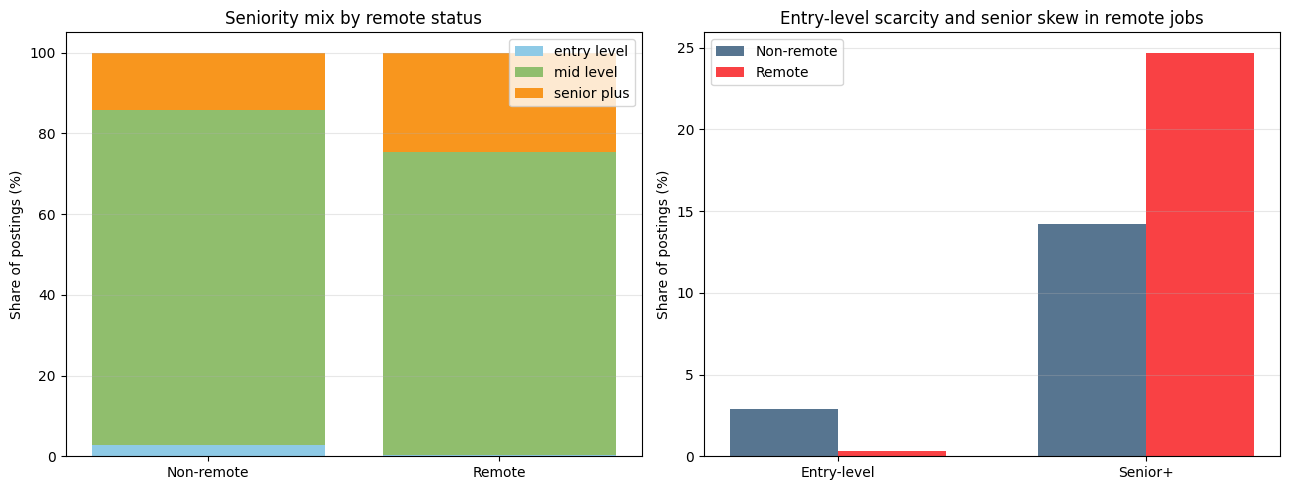

In [12]:
plot_table = share_table.copy()
colors = {'entry_level': '#8ecae6', 'mid_level': '#90be6d', 'senior_plus': '#f8961e'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bottom = np.zeros(len(plot_table))
for bucket in ['entry_level', 'mid_level', 'senior_plus']:
    axes[0].bar(plot_table.index, plot_table[bucket], bottom=bottom, label=bucket.replace('_', ' '), color=colors[bucket])
    bottom += plot_table[bucket].values
axes[0].set_ylabel('Share of postings (%)')
axes[0].set_title('Seniority mix by remote status')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

focus = pd.DataFrame({
    'Non-remote': [entry_nonremote, senior_nonremote],
    'Remote': [entry_remote, senior_remote],
}, index=['Entry-level', 'Senior+'])

x = np.arange(len(focus.index))
width = 0.35
axes[1].bar(x - width / 2, focus['Non-remote'], width, label='Non-remote', color='#577590')
axes[1].bar(x + width / 2, focus['Remote'], width, label='Remote', color='#f94144')
axes[1].set_xticks(x)
axes[1].set_xticklabels(focus.index)
axes[1].set_ylabel('Share of postings (%)')
axes[1].set_title('Entry-level scarcity and senior skew in remote jobs')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Conclusion

- Remote data science postings are much less entry-level friendly than non-remote ones.
- In this sample, only about **0.3%** of remote postings were classified as entry-level, versus about **2.9%** of non-remote postings.
- Remote postings were also much more senior-heavy: about **24.7%** were senior-plus, versus **14.2%** for non-remote postings.
- The difference is statistically significant (**chi-square p = 4.34e-07**), which supports the claim that remote filters tilt job seekers toward more experienced roles.
- Career Compass implication: entry-level candidates should be careful with remote-only search filters, because they sharply reduce exposure to beginner-friendly roles.

## Outputs for midterm report

* (1) Variable / Inputs: 2,317 unified job postings with usable location, split into Remote (328) and Non-remote (1,989), with title-derived seniority groups: Entry-level (59), Mid-level (1,894), and Senior+ (364).
* (2) Model (max 10 words): Chi-square test of remote status and title seniority.
* (3) Finding Statement (max 15 words): Remote data science jobs skew senior and are rarely entry-level.
* (4) Limitation or Extension of the Model/Findings (max 30 words): Seniority is inferred from job-title keywords and remote from location text; some roles may be mislabeled, and results reflect one cross-sectional sample rather than hiring causality.